Total files found: 38
Processing: sci_xrsf-l2-flx1s_g18_d20250207_v2-2-1.nc


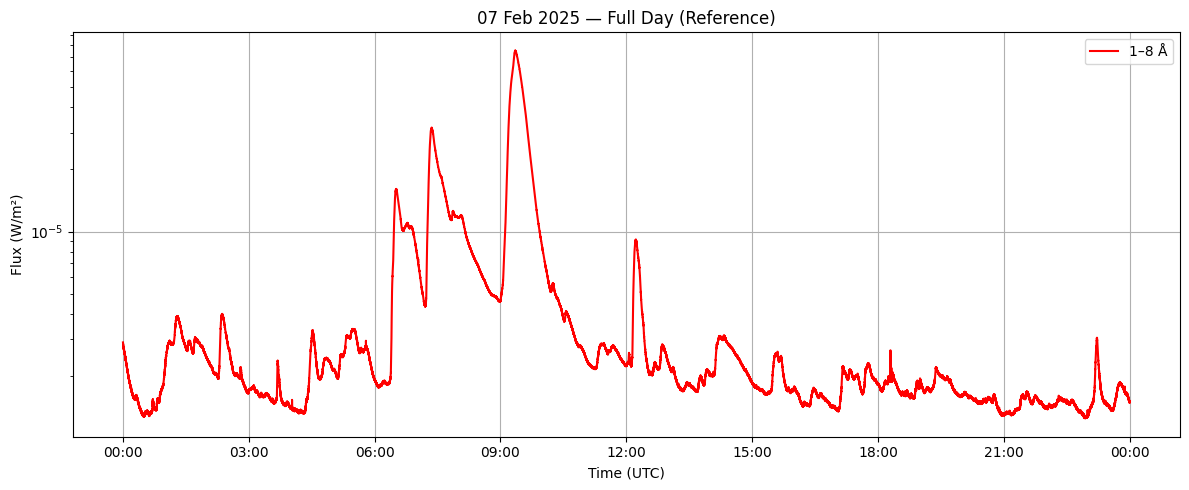

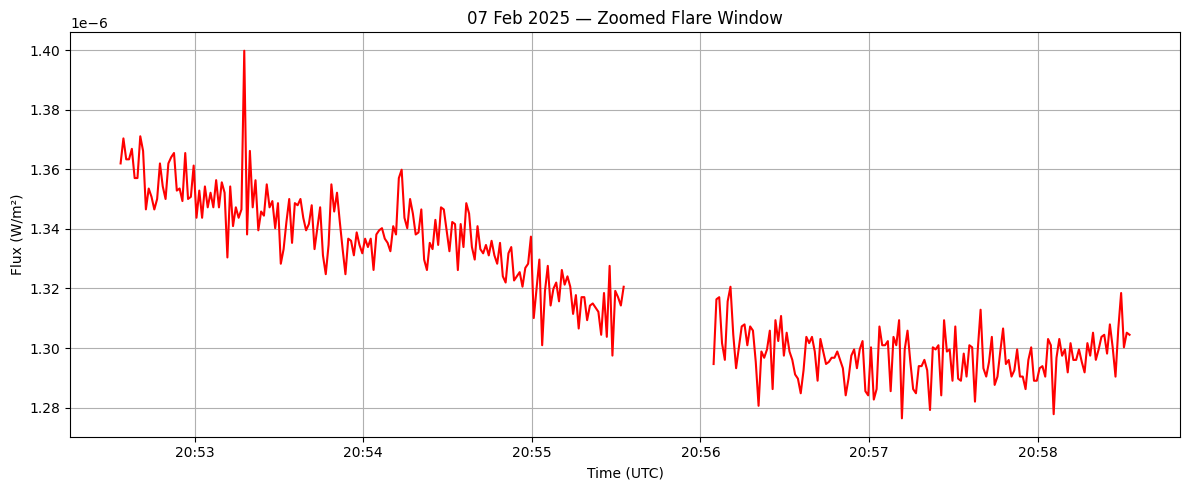

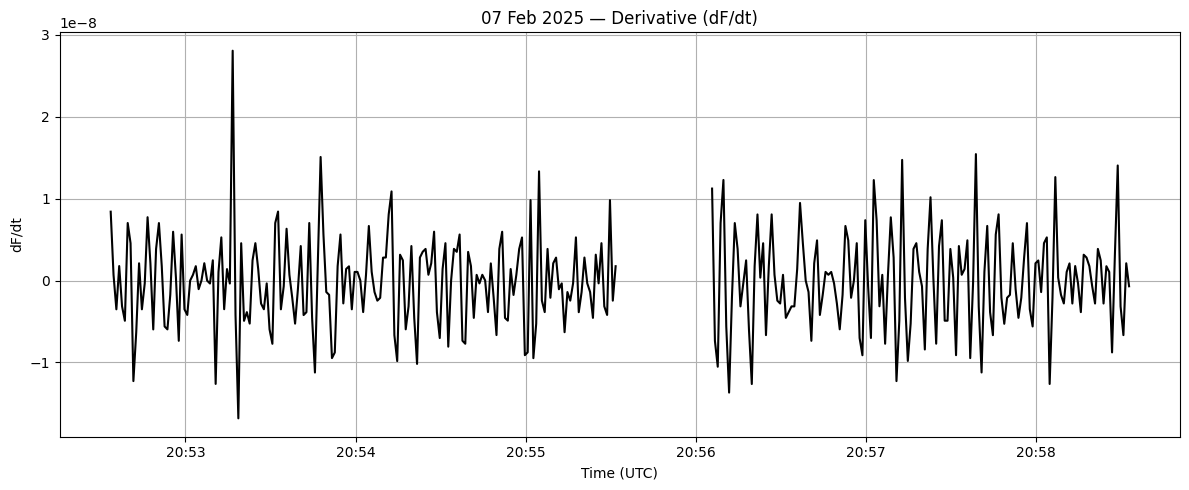

Processing: sci_xrsf-l2-flx1s_g18_d20250531_v2-2-1.nc


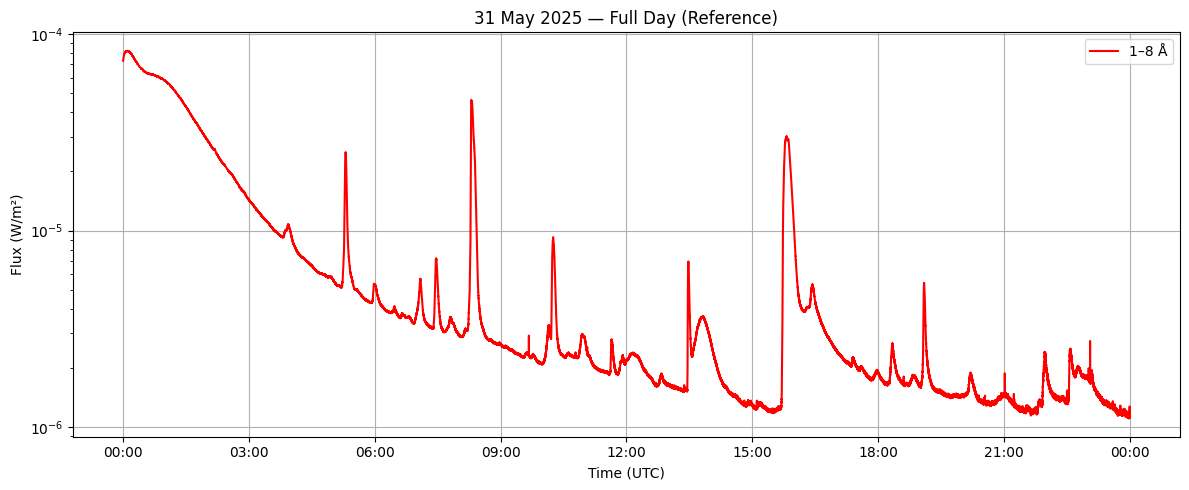

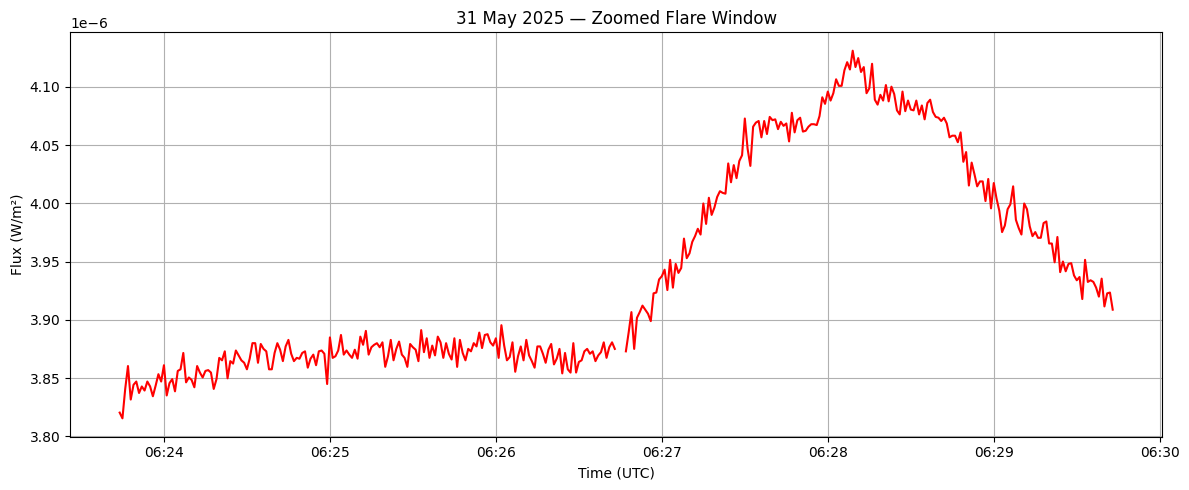

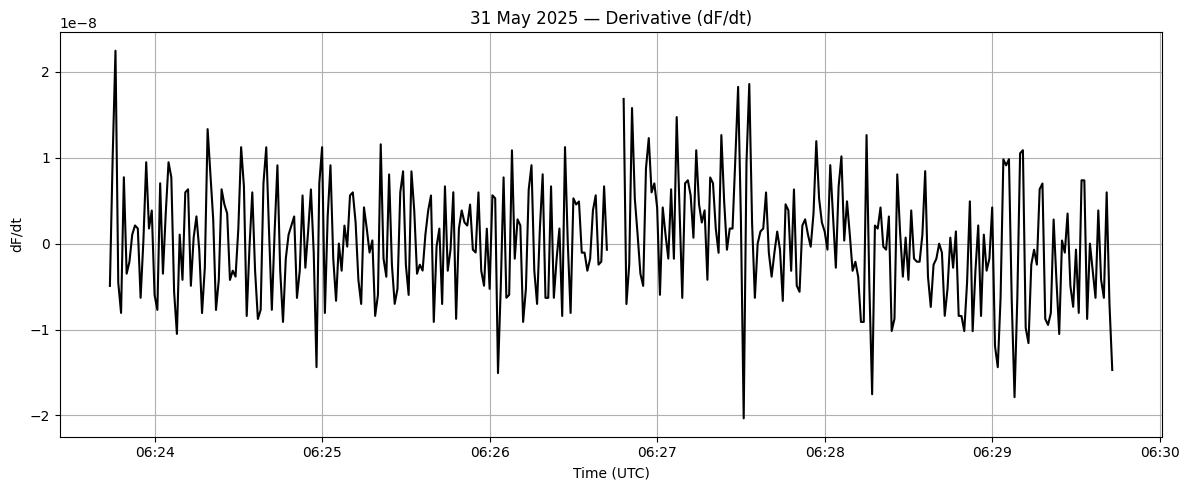

Processing: sci_xrsf-l2-flx1s_g18_d20251206_v2-2-1.nc


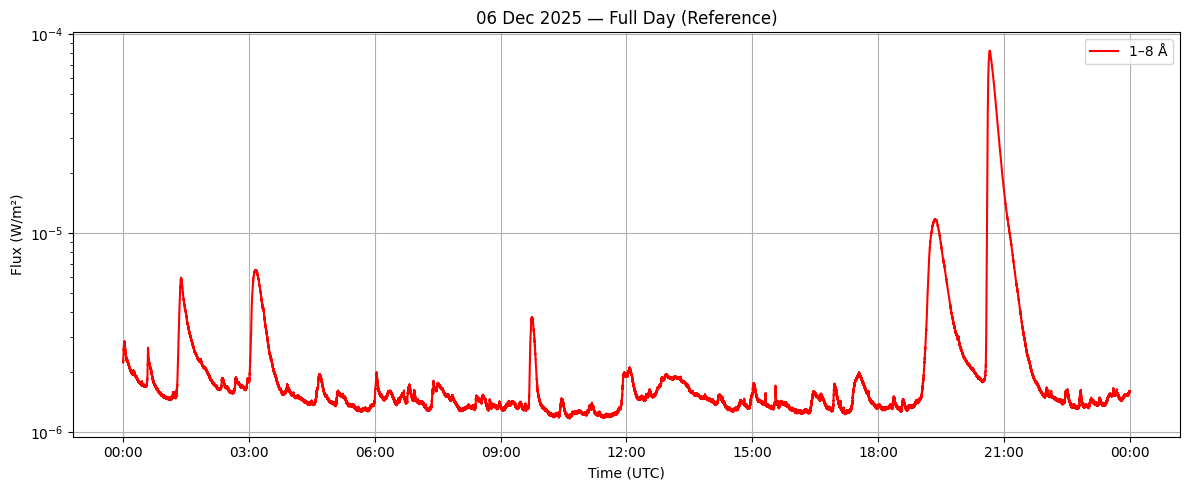

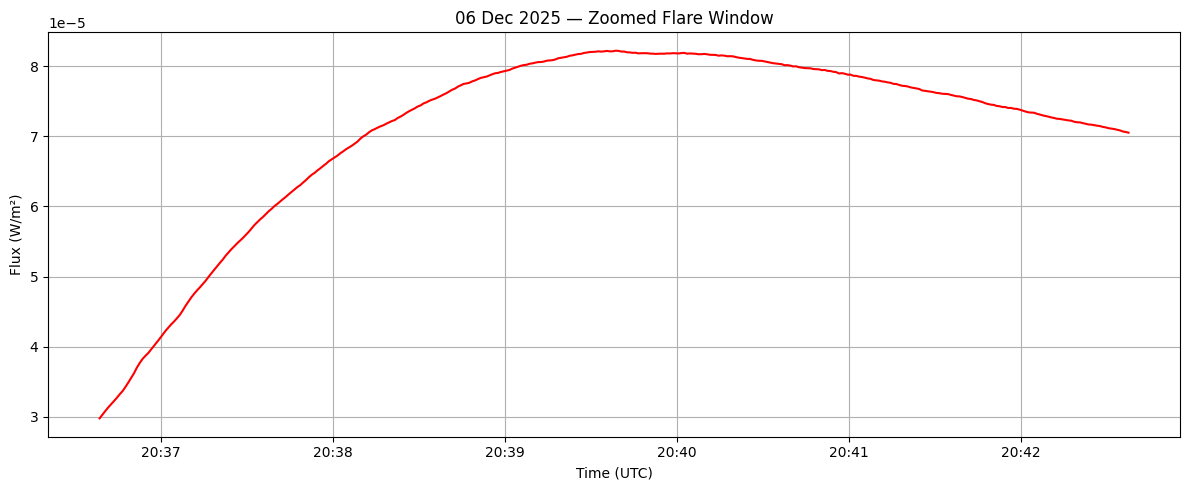

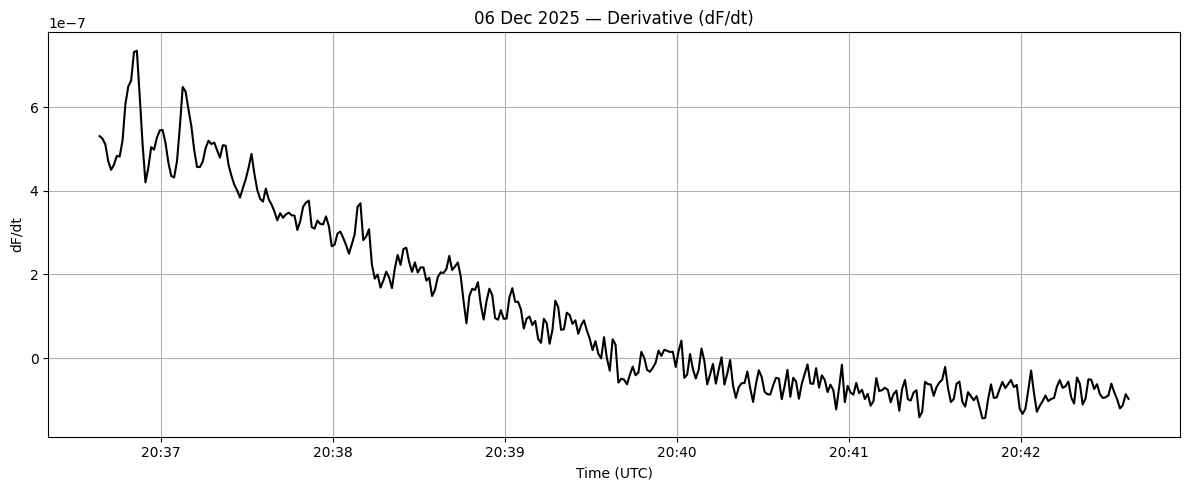

Processing: sci_xrsf-l2-flx1s_g18_d20251208_v2-2-1.nc


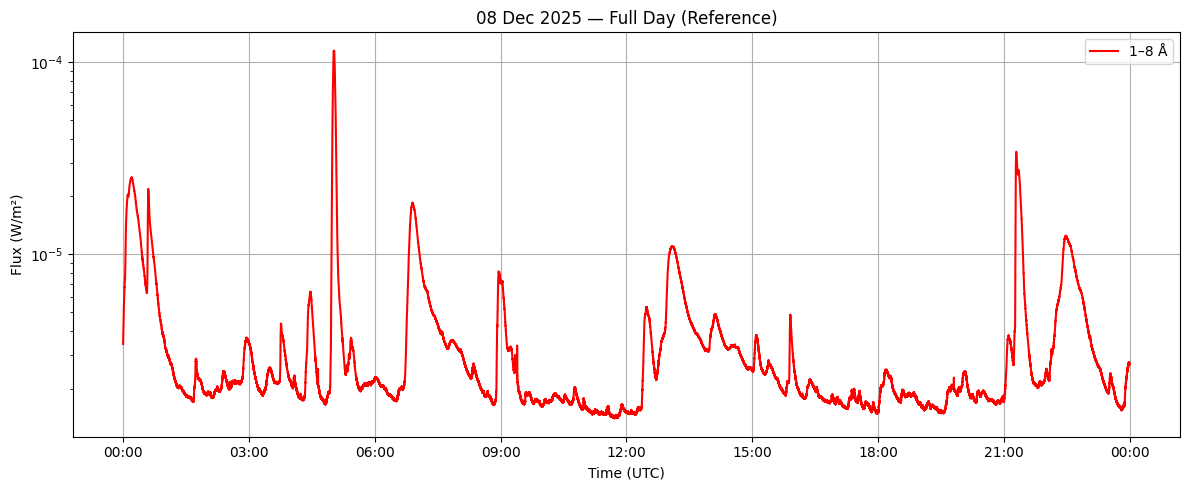

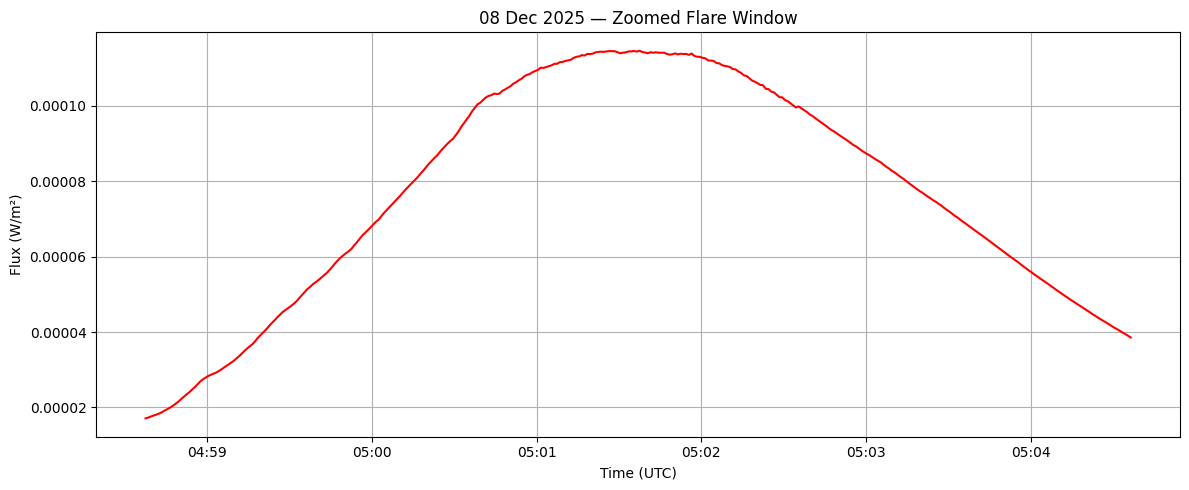

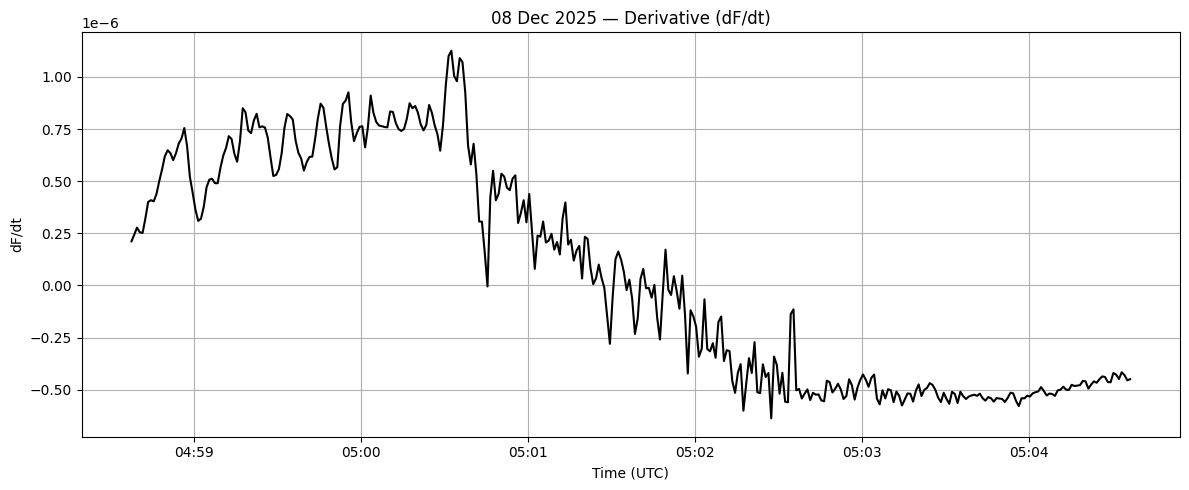

Processing: sci_xrsf-l2-flx1s_g18_d20251231_v2-2-1.nc


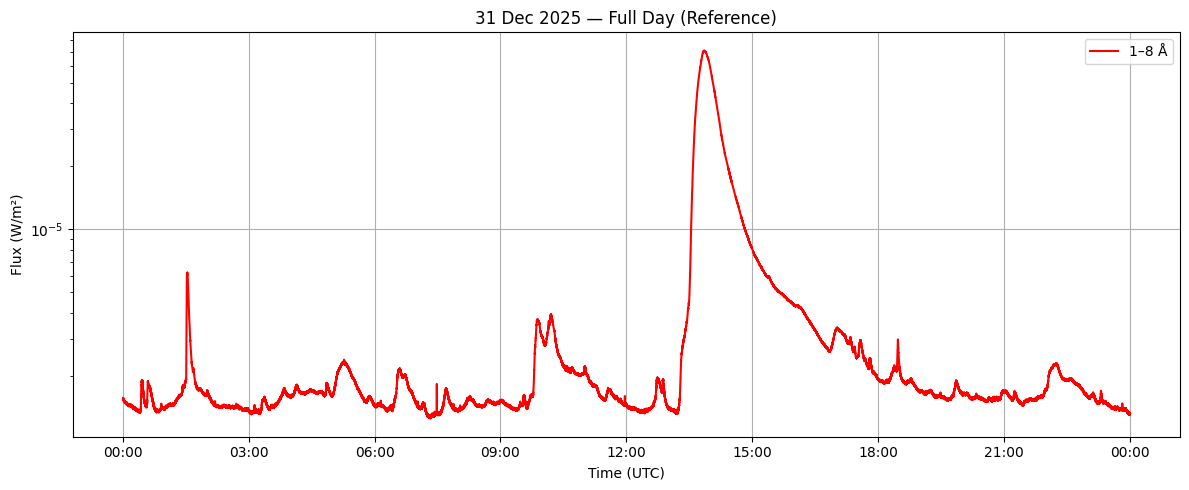

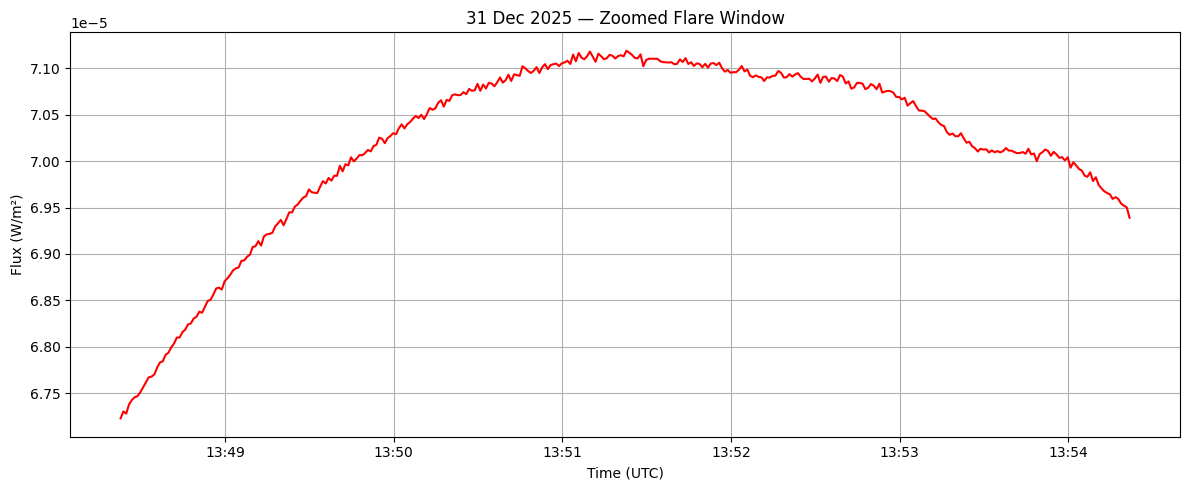

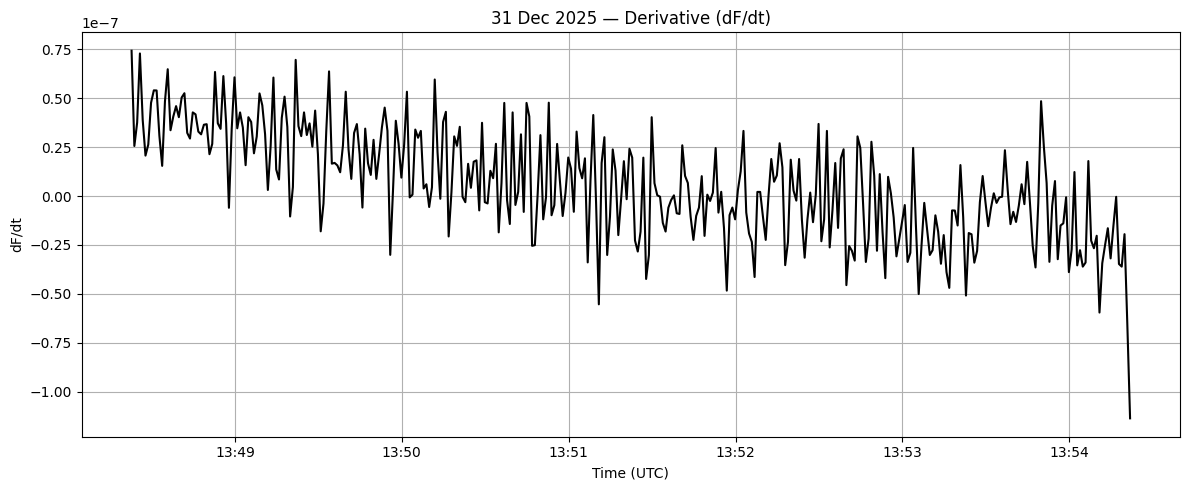

In [3]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
from datetime import datetime
import numpy as np

# --------------------------------
# Folder containing GOES files
# --------------------------------

folder = "/media/hp/TOSHIBA EXT/2025 Analysis"

# --------------------------------
# TARGET DATES (only selected events)
# --------------------------------

target_dates = [
    "20250531",
    "20251206",
    "20251208",
    "20250207",
    "20251231"
]

# --------------------------------
# Get all files
# --------------------------------

files = sorted([f for f in os.listdir(folder) if f.endswith(".nc")])

print("Total files found:", len(files))


# --------------------------------
# Loop through files
# --------------------------------

for f in files:

    date_string = f.split("_d")[1][:8]

    # Skip unwanted files
    if date_string not in target_dates:
        continue

    filepath = os.path.join(folder, f)

    print("Processing:", f)

    # --------------------------------
    # Date formatting
    # --------------------------------

    date_obj = datetime.strptime(date_string, "%Y%m%d")
    title_date = date_obj.strftime("%d %b %Y")

    # --------------------------------
    # Load dataset
    # --------------------------------

    ds = xr.open_dataset(filepath)

    time = ds["time"].values
    flux_long = ds["xrsb_flux"].values  # 1–8 Å

    t = Time(time).datetime


    # --------------------------------
    # FULL DAY PLOT (REFERENCE)
    # --------------------------------

    plt.figure(figsize=(12,5))

    plt.plot(t, flux_long, color="red", label="1–8 Å")

    plt.yscale("log")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.title(f"{title_date} — Full Day (Reference)")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Flux (W/m²)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # --------------------------------
    # FIND PEAK AND ZOOM WINDOW
    # --------------------------------

    peak_index = np.argmax(flux_long)

    window = 180   # adjust if needed

    start = max(0, peak_index - window)
    end   = min(len(flux_long), peak_index + window)

    t_zoom = t[start:end]
    flux_zoom = flux_long[start:end]


    # --------------------------------
    # ZOOMED FLARE PLOT
    # --------------------------------

    plt.figure(figsize=(12,5))

    plt.plot(t_zoom, flux_zoom, color="red")

    plt.title(f"{title_date} — Zoomed Flare Window")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Flux (W/m²)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # --------------------------------
    # 🔥 DERIVATIVE (VERY IMPORTANT)
    # --------------------------------

    flux_deriv = np.gradient(flux_zoom)


    # --------------------------------
    # DERIVATIVE PLOT
    # --------------------------------

    plt.figure(figsize=(12,5))

    plt.plot(t_zoom, flux_deriv, color="black")

    plt.title(f"{title_date} — Derivative (dF/dt)")
    plt.xlabel("Time (UTC)")
    plt.ylabel("dF/dt")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # --------------------------------
    # CLOSE DATASET
    # --------------------------------

    ds.close()